In [25]:
import pandas as pd

In [26]:
#load the data
df = pd.read_csv("telco_churn_unclean.csv")
print("Raw shape:", df.shape)
df.head()

Raw shape: (7048, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,Yes,DSL,No,...,No,No,No,No,month to month,Yes,Electronic check,$29.85,NaN,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.3,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.7,151.65,Yes


In [27]:
#check data types and missing values
df.info()
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7048 entries, 0 to 7047
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   customerID        7048 non-null   object
 1   gender            7048 non-null   object
 2   SeniorCitizen     7048 non-null   int64 
 3   Partner           7048 non-null   object
 4   Dependents        7048 non-null   object
 5   tenure            7048 non-null   int64 
 6   PhoneService      7048 non-null   object
 7   MultipleLines     7048 non-null   object
 8   InternetService   7048 non-null   object
 9   OnlineSecurity    7048 non-null   object
 10  OnlineBackup      7048 non-null   object
 11  DeviceProtection  7048 non-null   object
 12  TechSupport       7048 non-null   object
 13  StreamingTV       7048 non-null   object
 14  StreamingMovies   7048 non-null   object
 15  Contract          7048 non-null   object
 16  PaperlessBilling  7048 non-null   object
 17  PaymentMethod 

In [28]:
#clean MonthlyCharges
df["MonthlyCharges"] = df["MonthlyCharges"].astype(str)
df["MonthlyCharges"] = df["MonthlyCharges"].str.replace("$", "", regex=False)
df["MonthlyCharges"] = df["MonthlyCharges"].str.replace(",", "", regex=False)
df["MonthlyCharges"] = pd.to_numeric(df["MonthlyCharges"], errors="coerce")

In [29]:
#clean TotalCharges
df["TotalCharges"] = df["TotalCharges"].astype(str)
df["TotalCharges"] = df["TotalCharges"].str.replace("$", "", regex=False)
df["TotalCharges"] = df["TotalCharges"].str.replace(",", "", regex=False)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [30]:
#remove missing values and duplicates
df = df.dropna()
df = df.drop_duplicates()
print("Shape after cleaning:", df.shape)

Shape after cleaning: (6910, 21)


In [31]:
#change SeniorCitizen from 0/1 to No/Yes
df["SeniorCitizen"] = df["SeniorCitizen"].replace({0: "No", 1: "Yes"})
print(df["SeniorCitizen"].value_counts())

SeniorCitizen
No     5791
Yes    1119
Name: count, dtype: int64


In [32]:
#create ChurnFlag column
df["ChurnFlag"] = df["Churn"].map({"Yes": 1, "No": 0})

In [33]:
#create TenureGroup column
df["TenureGroup"] = pd.cut(
    df["tenure"],
    bins=[0, 12, 24, 48, 72],
    labels=["0-12 months", "13-24 months", "25-48 months", "49-72 months"],
    include_lowest=True
)

In [34]:
   df["Contract"] = df["Contract"].replace({"month to month": "Month-to-month"})
   print(df["Contract"].value_counts())

Contract
Month-to-month    3753
Two year          1685
One year          1472
Name: count, dtype: int64


In [35]:
print("Final shape:", df.shape)
df.to_csv("telco_churn_cleaned_python.csv", index=False)

Final shape: (6910, 23)


In [36]:
import matplotlib.pyplot as plt

churn count

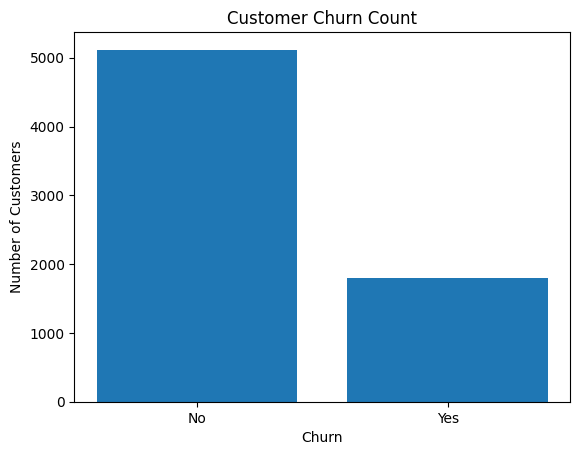

In [37]:
churn_counts = df["Churn"].value_counts()

plt.bar(churn_counts.index, churn_counts.values)
plt.title("Customer Churn Count")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.savefig("churn_count.png")
plt.show()

churn rate by contract

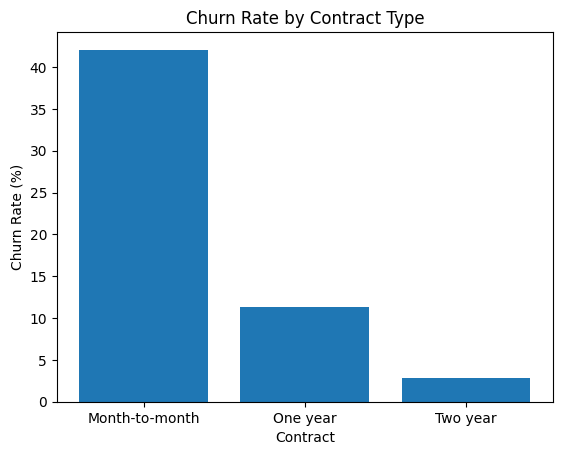

In [38]:
contract_rate = df.groupby("Contract")["ChurnFlag"].mean() * 100

plt.bar(contract_rate.index, contract_rate.values)
plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract")
plt.ylabel("Churn Rate (%)")
plt.savefig("churn_by_contract.png")
plt.show()

churn rate by internet service

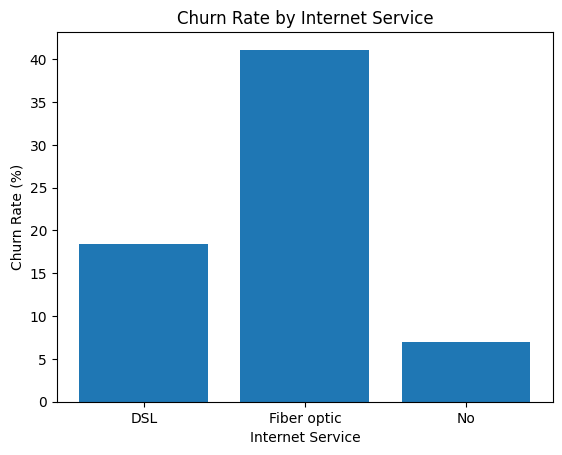

In [39]:
internet_rate = df.groupby("InternetService")["ChurnFlag"].mean() * 100

plt.bar(internet_rate.index, internet_rate.values)
plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Churn Rate (%)")
plt.savefig("churn_by_internet.png")
plt.show()

churn rate by payment method

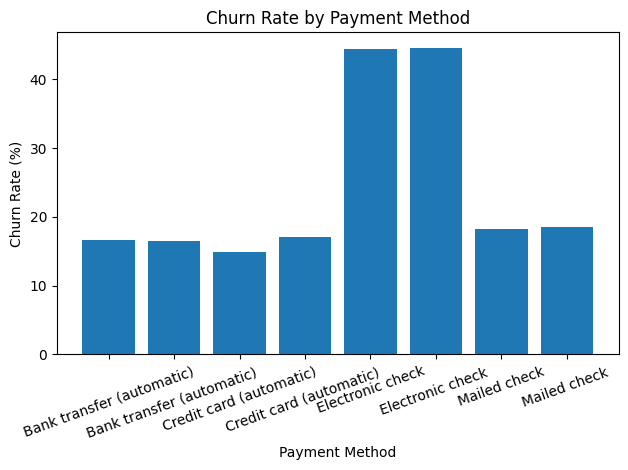

In [40]:
payment_rate = df.groupby("PaymentMethod")["ChurnFlag"].mean() * 100

plt.bar(payment_rate.index, payment_rate.values)
plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("churn_by_payment.png")
plt.show()

churn rate by tenure group

/tmp/ipykernel_1831/4035949776.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tenure_rate = df.groupby("TenureGroup")["ChurnFlag"].mean() * 100


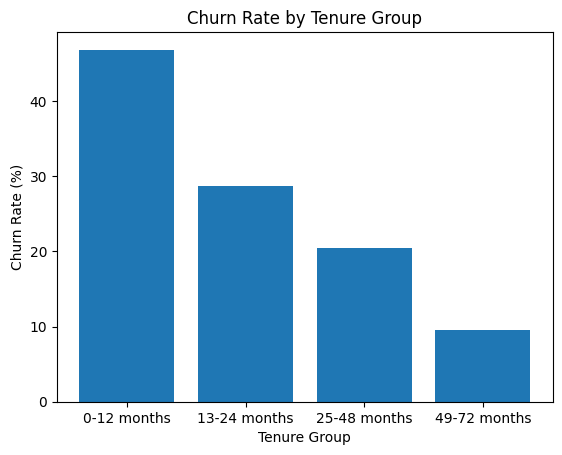

In [41]:
tenure_rate = df.groupby("TenureGroup")["ChurnFlag"].mean() * 100

plt.bar(tenure_rate.index, tenure_rate.values)
plt.title("Churn Rate by Tenure Group")
plt.xlabel("Tenure Group")
plt.ylabel("Churn Rate (%)")
plt.savefig("churn_by_tenure.png")
plt.show()

churn rate by senior citizen

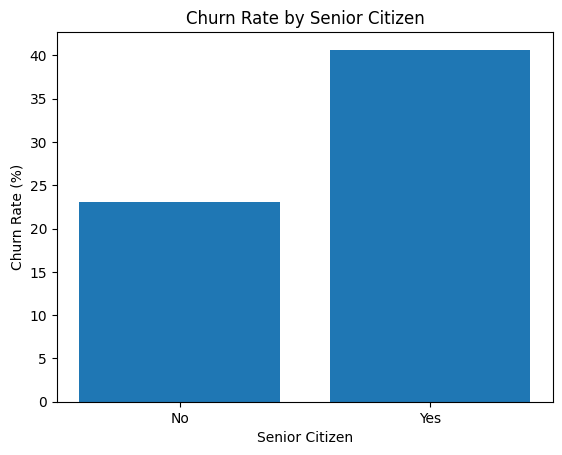

In [42]:
senior_rate = df.groupby("SeniorCitizen")["ChurnFlag"].mean() * 100

plt.bar(senior_rate.index, senior_rate.values)
plt.title("Churn Rate by Senior Citizen")
plt.xlabel("Senior Citizen")
plt.ylabel("Churn Rate (%)")
plt.savefig("churn_by_senior.png")
plt.show()

average monthly charges by churn

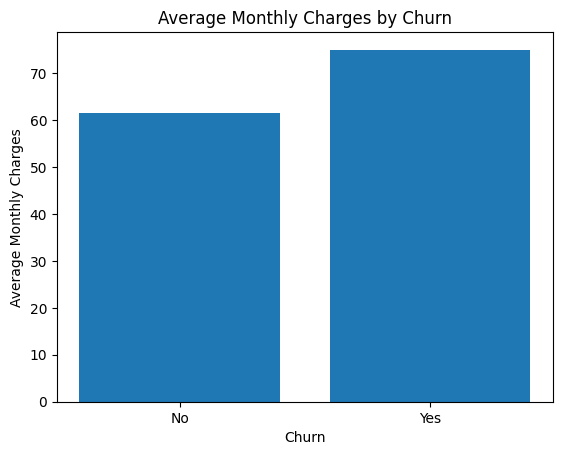

In [43]:
avg_charges = df.groupby("Churn")["MonthlyCharges"].mean()

plt.bar(avg_charges.index, avg_charges.values)
plt.title("Average Monthly Charges by Churn")
plt.xlabel("Churn")
plt.ylabel("Average Monthly Charges")
plt.savefig("charts_by_churn.png")
plt.show()